
--- Running Dynamic Programming for Gamma = 0.9 ---
  -> Value Iteration converged in 52 iterations.
  -> Max Value discrepancy between VI and PI: 8.68e-09

--- Running Dynamic Programming for Gamma = 0.95 ---
  -> Value Iteration converged in 57 iterations.
  -> Max Value discrepancy between VI and PI: 8.67e-09

--- Running Dynamic Programming for Gamma = 0.99 ---
  -> Value Iteration converged in 61 iterations.
  -> Max Value discrepancy between VI and PI: 1.19e-08

--- Running Dynamic Programming for Gamma = 0.999 ---
  -> Value Iteration converged in 62 iterations.
  -> Max Value discrepancy between VI and PI: 1.20e-08

Preparing final visualization...
State Values visual plot saved as 'mdp_optimal_values.png'.


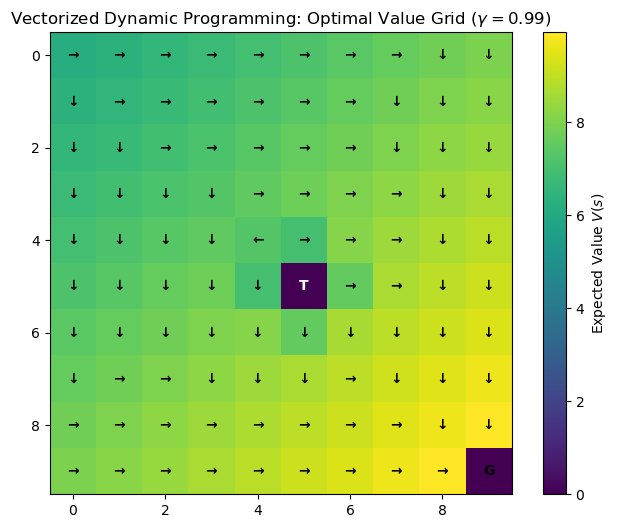

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

class VectorizedStochasticGridWorld:
    def __init__(self, height=10, width=10, slip_prob=0.15, step_cost=-0.1):
        """Initializes the grid world environment properties."""
        self.height = height
        self.width = width
        self.num_states = height * width
        self.num_actions = 4  # 0: Up, 1: Down, 2: Left, 3: Right
        
        self.goal_state = self.num_states - 1  # Bottom-right
        self.trap_state = 55                   # Center tile
        
        self.slip_prob = slip_prob
        self.step_cost = step_cost
        
        # Initialize transition and reward tensors
        self.P = np.zeros((self.num_states, self.num_actions, self.num_states))
        self.R = np.zeros((self.num_states, self.num_actions))
        
        self._build_world()

    def _build_world(self):
        """Constructs the dense transition (P) and reward (R) matrices."""
        intended_prob = 1.0 - self.slip_prob
        slip_prob_each = self.slip_prob / 3.0  # Distributed equally among remaining 3 directions
        
        for s in range(self.num_states):
            if s == self.goal_state or s == self.trap_state:
                # Terminal states: absorbing loop
                for a in range(self.num_actions):
                    self.P[s, a, s] = 1.0
                continue
                
            r, c = s // self.width, s % self.width
            
            # Map out coordinates if we went Up, Down, Left, or Right
            neighbors = {
                0: (max(r - 1, 0), c),                   # Up
                1: (min(r + 1, self.height - 1), c),     # Down
                2: (r, max(c - 1, 0)),                   # Left
                3: (r, min(c + 1, self.width - 1))       # Right
            }
            
            for a in range(self.num_actions):
                # 1. Setup intended move probability
                intended_state = neighbors[a][0] * self.width + neighbors[a][1]
                self.P[s, a, intended_state] += intended_prob
                
                # 2. Setup unintended slip probabilities
                for slip_action in range(self.num_actions):
                    if slip_action != a:
                        slip_state = neighbors[slip_action][0] * self.width + neighbors[slip_action][1]
                        self.P[s, a, slip_state] += slip_prob_each
                
                # 3. Define Reward Matrix
                for s_next in range(self.num_states):
                    prob = self.P[s, a, s_next]
                    if prob > 0:
                        if s_next == self.goal_state:
                            self.R[s, a] += prob * 10.0
                        elif s_next == self.trap_state:
                            self.R[s, a] += prob * -10.0
                        else:
                            self.R[s, a] += prob * self.step_cost

class DynamicProgrammingSolver:
    def __init__(self, env, gamma=0.99):
        """Initializes the solver with a specific environment and discount factor."""
        self.env = env
        self.gamma = gamma

    def value_iteration(self, theta=1e-8, max_iters=1000):
        """Iteratively updates state values using Bellman Optimality Equation."""
        V = np.zeros(self.env.num_states)
        history = []
        
        for i in range(max_iters):
            # Tensor dot product to compute Q-values simultaneously
            Q = self.env.R + self.gamma * np.tensordot(self.env.P, V, axes=(2, 0))
            
            # Extract the maximum value over actions for each state
            V_new = np.max(Q, axis=1)
            
            delta = np.max(np.abs(V_new - V))
            history.append(delta)
            
            V = V_new
            if delta < theta:
                print(f"  -> Value Iteration converged in {i+1} iterations.")
                break
                
        # Extract optimal policy
        final_Q = self.env.R + self.gamma * np.tensordot(self.env.P, V, axes=(2, 0))
        optimal_policy = np.argmax(final_Q, axis=1)
        
        return V, optimal_policy, history

    def policy_iteration(self, max_iters=100):
        """Finds optimal policy using exact linear system evaluation and improvement."""
        policy = np.zeros(self.env.num_states, dtype=int)
        V = np.zeros(self.env.num_states)
        state_indices = np.arange(self.env.num_states)
        
        for i in range(max_iters):
            # 1. Policy Evaluation (Exact)
            P_pi = self.env.P[state_indices, policy, :]
            R_pi = self.env.R[state_indices, policy]
            
            A = np.eye(self.env.num_states) - self.gamma * P_pi
            V = scipy.linalg.solve(A, R_pi)
            
            # 2. Policy Improvement
            Q = self.env.R + self.gamma * np.tensordot(self.env.P, V, axes=(2, 0))
            new_policy = np.argmax(Q, axis=1)
            
            if np.array_equal(new_policy, policy):
                print(f"  -> Policy Iteration converged in {i+1} iterations.")
                break
                
            policy = new_policy
            
        return V, policy

if __name__ == "__main__":
    # Initialize the stochastic Grid-World
    env = VectorizedStochasticGridWorld(height=10, width=10, slip_prob=0.15, step_cost=-0.1)
    
    # Analyze multiple discount factors gamma
    discount_factors = [0.9, 0.95, 0.99, 0.999]
    
    for gamma in discount_factors:
        print(f"\n--- Running Dynamic Programming for Gamma = {gamma} ---")
        solver = DynamicProgrammingSolver(env, gamma=gamma)
        
        # Run Value Iteration
        v_vi, pi_vi, hist_vi = solver.value_iteration()
        # Run Policy Iteration
        v_pi, pi_pi = solver.policy_iteration()
        
        # Verify that Value Iteration and Policy Iteration yield mathematically identical values
        max_diff = np.max(np.abs(v_vi - v_pi))
        print(f"  -> Max Value discrepancy between VI and PI: {max_diff:.2e}")
        
    # Render the optimal path topology using Gamma=0.99
    print("\nPreparing final visualization...")
    solver = DynamicProgrammingSolver(env, gamma=0.99)
    optimal_values, optimal_policy = solver.policy_iteration()
    
    # Plot final State Values Heatmap 
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.imshow(optimal_values.reshape((10, 10)), cmap="viridis", origin="upper")
    fig.colorbar(cax, label="Expected Value $V(s)$")
    ax.set_title(r"Vectorized Dynamic Programming: Optimal Value Grid ($\gamma=0.99$)")
    
    # Render Policy arrows
    arrows = {0: "↑", 1: "↓", 2: "←", 3: "→"}
    for r in range(10):
        for c in range(10):
            idx = r * 10 + c
            if idx == env.goal_state:
                label = "G"
            elif idx == env.trap_state:
                label = "T"
            else:
                label = arrows[optimal_policy[idx]]
            
            # Choose text color based on background heat to ensure readability
            text_color = "white" if optimal_values[idx] < 0 else "black"
            ax.text(c, r, label, ha="center", va="center", color=text_color, fontweight="bold")
            
    print("State Values visual plot saved as 'mdp_optimal_values.png'.")
    plt.savefig("mdp_optimal_values.png")
    
    # Automatically show the plot when running in a notebook/UI
0.

plt.show()
    plt.close()